FIRST FIVE ROWS
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No D

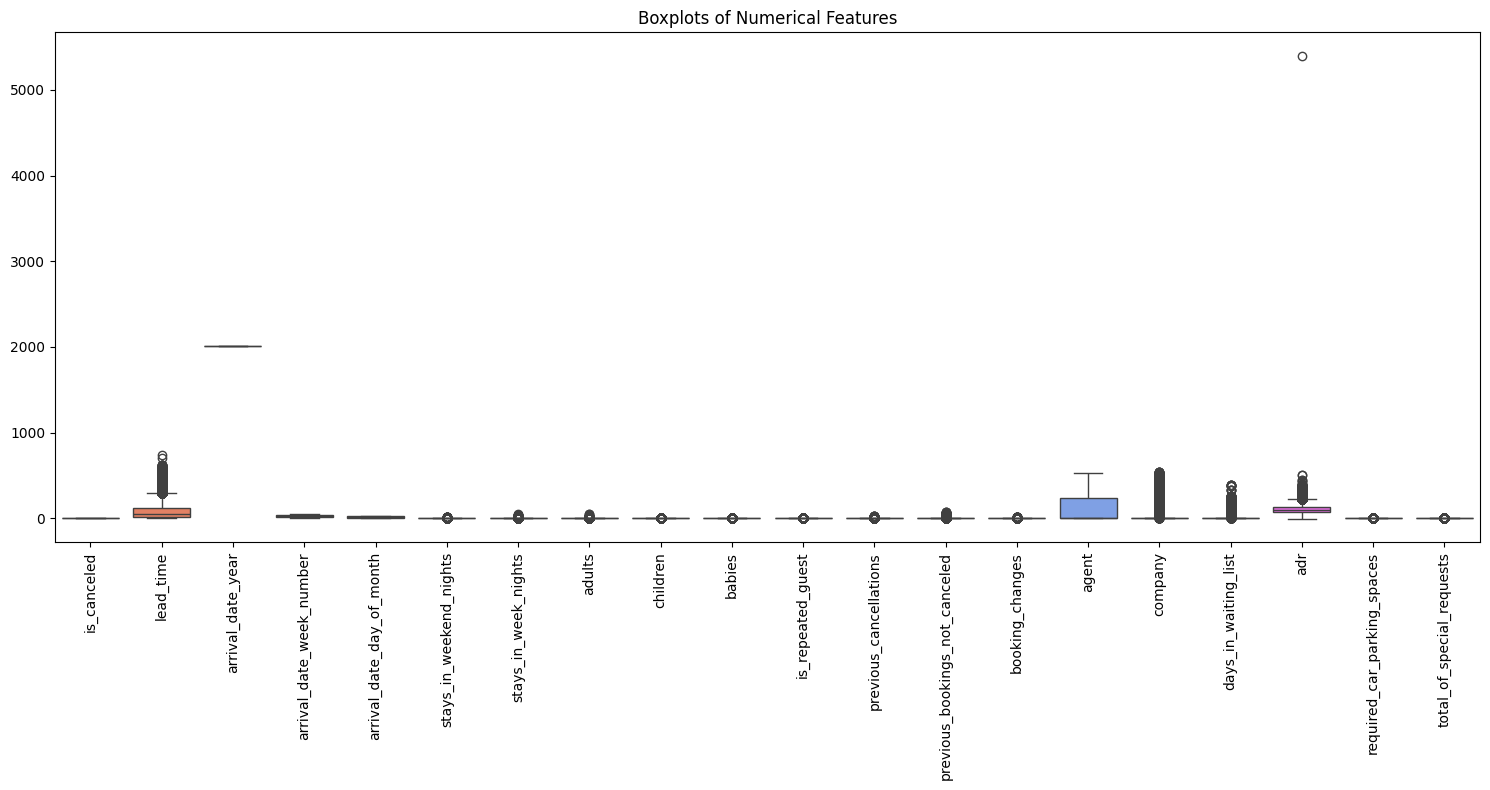

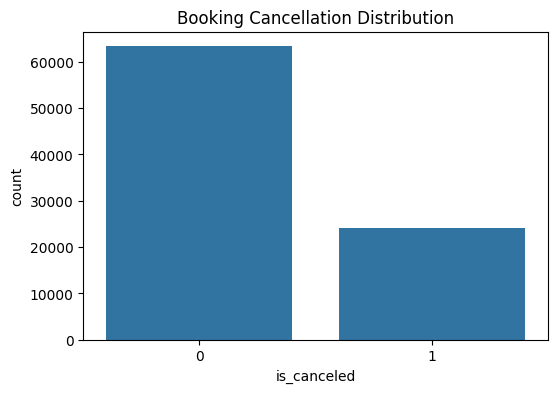

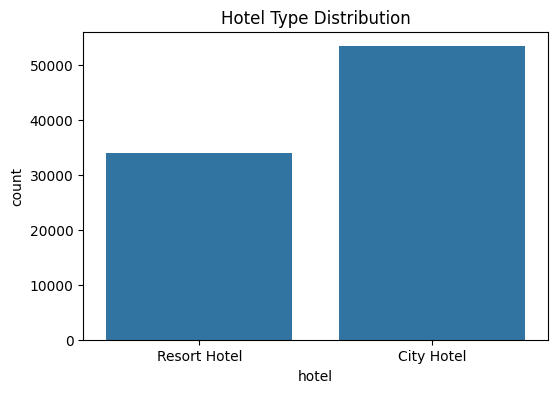

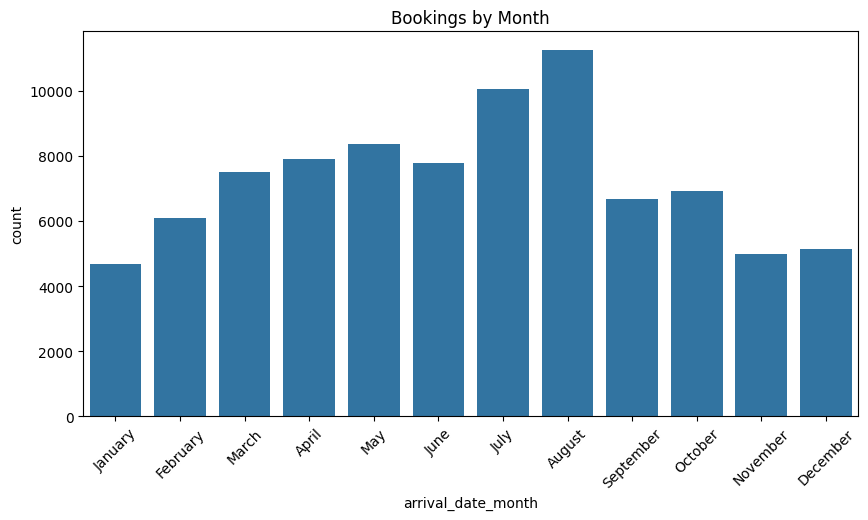

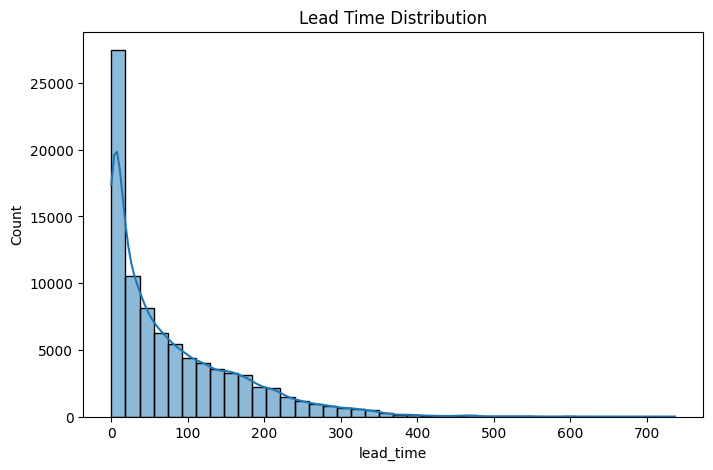

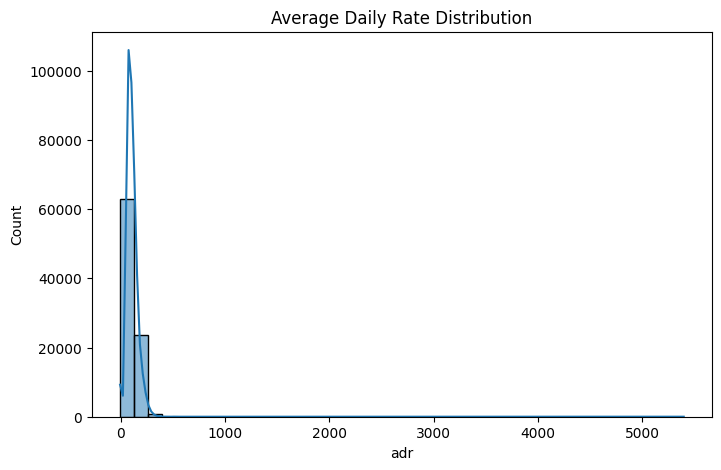

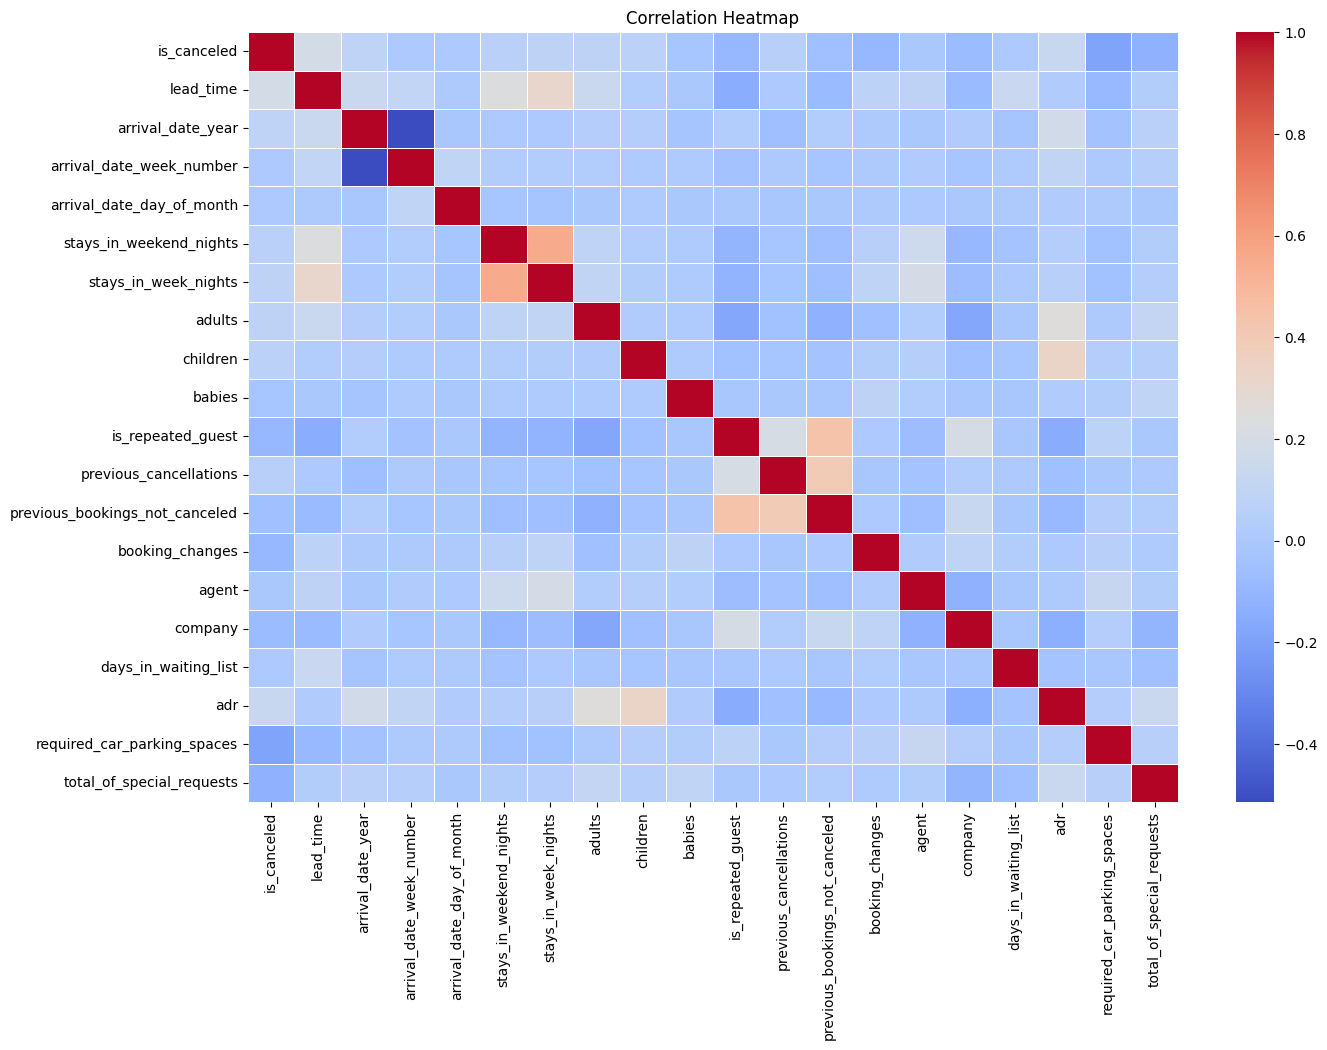

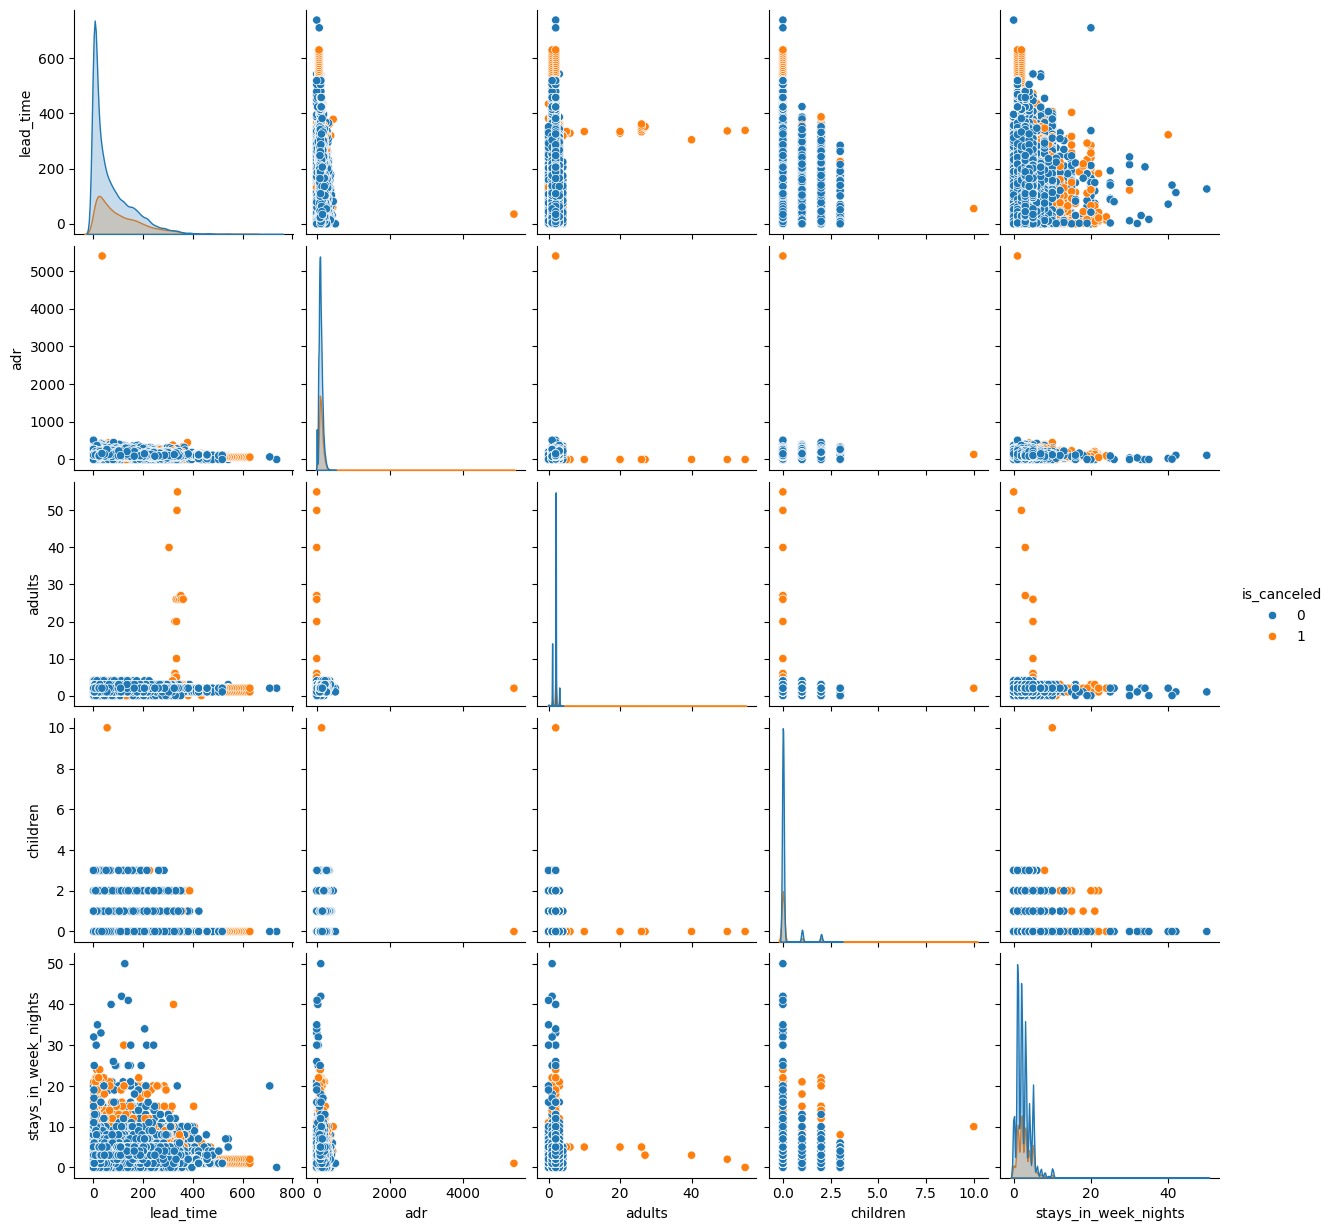

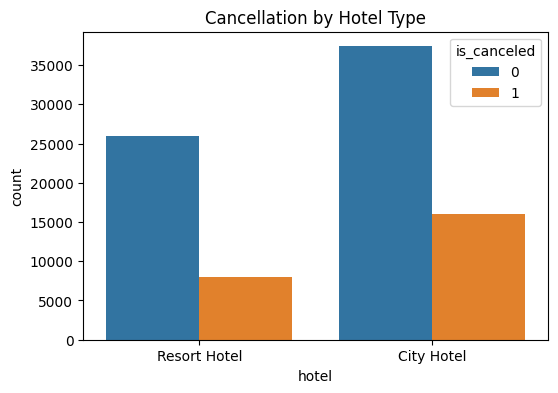

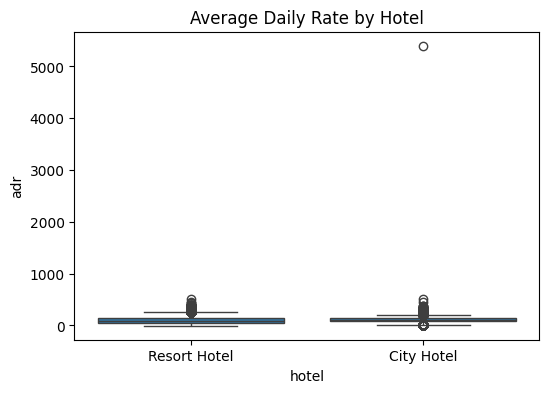

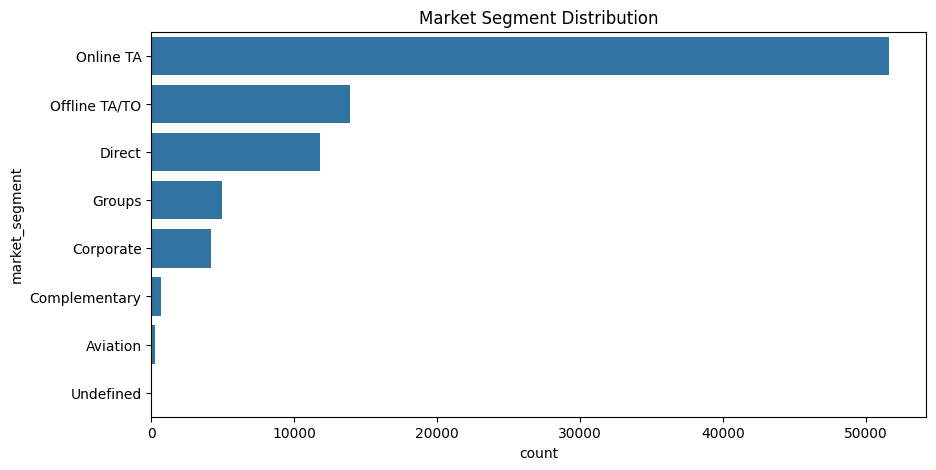

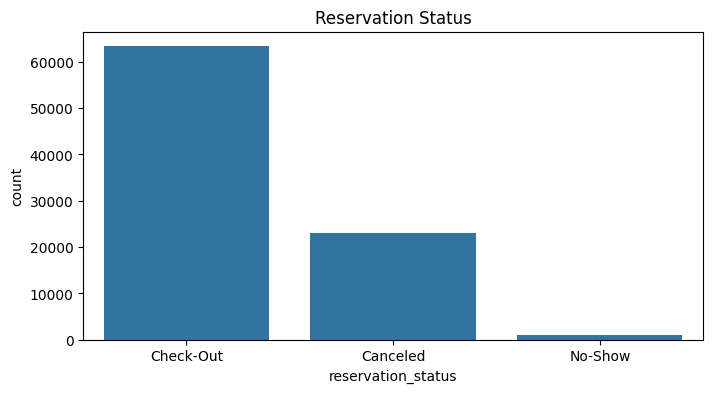


Numerical Feature Summary
        is_canceled     lead_time  arrival_date_year  \
count  87377.000000  87377.000000       87377.000000   
mean       0.274946     79.905856        2016.210273   
std        0.446490     86.055523           0.686124   
min        0.000000      0.000000        2015.000000   
25%        0.000000     11.000000        2016.000000   
50%        0.000000     49.000000        2016.000000   
75%        1.000000    125.000000        2017.000000   
max        1.000000    737.000000        2017.000000   

       arrival_date_week_number  arrival_date_day_of_month  \
count              87377.000000               87377.000000   
mean                  26.840107                  15.815203   
std                   13.673425                   8.834744   
min                    1.000000                   1.000000   
25%                   16.000000                   8.000000   
50%                   27.000000                  16.000000   
75%                   37.000000   

In [1]:
# ==========================================================
# Advanced Data Mining Project - Deliverable 1
# Data Collection, Cleaning, and Exploration
# ==========================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------
df = pd.read_csv("hotel_bookings.csv")

print("="*60)
print("FIRST FIVE ROWS")
print("="*60)
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information")
print(df.info())

print("\nSummary Statistics")
print(df.describe(include='all'))

# ----------------------------------------------------------
# Missing Values
# ----------------------------------------------------------
print("\nMissing Values")
print(df.isnull().sum())

# Fill missing values
df['children'] = df['children'].fillna(df['children'].median())
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# ----------------------------------------------------------
# Remove Duplicate Records
# ----------------------------------------------------------
duplicates = df.duplicated().sum()
print("\nDuplicate Records:", duplicates)

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)

# ----------------------------------------------------------
# Check Data Types
# ----------------------------------------------------------
print("\nData Types")
print(df.dtypes)

# ----------------------------------------------------------
# Detect Outliers (Numerical Features)
# ----------------------------------------------------------
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,8))
sns.boxplot(data=df[numeric_cols])
plt.xticks(rotation=90)
plt.title("Boxplots of Numerical Features")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Distribution of Target Variable
# ----------------------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='is_canceled', data=df)
plt.title("Booking Cancellation Distribution")
plt.show()

# ----------------------------------------------------------
# Hotel Type Distribution
# ----------------------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='hotel', data=df)
plt.title("Hotel Type Distribution")
plt.show()

# ----------------------------------------------------------
# Arrival Month Distribution
# ----------------------------------------------------------
plt.figure(figsize=(10,5))
sns.countplot(x='arrival_date_month', data=df,
              order=['January','February','March','April','May','June',
                     'July','August','September','October','November','December'])
plt.xticks(rotation=45)
plt.title("Bookings by Month")
plt.show()

# ----------------------------------------------------------
# Lead Time Distribution
# ----------------------------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['lead_time'], bins=40, kde=True)
plt.title("Lead Time Distribution")
plt.show()

# ----------------------------------------------------------
# Average Daily Rate Distribution
# ----------------------------------------------------------
plt.figure(figsize=(8,5))
sns.histplot(df['adr'], bins=40, kde=True)
plt.title("Average Daily Rate Distribution")
plt.show()

# ----------------------------------------------------------
# Correlation Heatmap
# ----------------------------------------------------------
plt.figure(figsize=(15,10))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

# ----------------------------------------------------------
# Pairplot (Selected Variables)
# ----------------------------------------------------------
selected = ['lead_time',
            'adr',
            'adults',
            'children',
            'stays_in_week_nights',
            'is_canceled']

sns.pairplot(df[selected], hue='is_canceled')
plt.show()

# ----------------------------------------------------------
# Booking Status by Hotel
# ----------------------------------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='hotel',
              hue='is_canceled',
              data=df)

plt.title("Cancellation by Hotel Type")
plt.show()

# ----------------------------------------------------------
# ADR by Hotel
# ----------------------------------------------------------
plt.figure(figsize=(6,4))
sns.boxplot(x='hotel',
            y='adr',
            data=df)

plt.title("Average Daily Rate by Hotel")
plt.show()

# ----------------------------------------------------------
# Market Segment Distribution
# ----------------------------------------------------------
plt.figure(figsize=(10,5))
sns.countplot(y='market_segment',
              data=df,
              order=df['market_segment'].value_counts().index)

plt.title("Market Segment Distribution")
plt.show()

# ----------------------------------------------------------
# Reservation Status Distribution
# ----------------------------------------------------------
plt.figure(figsize=(8,4))
sns.countplot(x='reservation_status',
              data=df)

plt.title("Reservation Status")
plt.show()

# ----------------------------------------------------------
# Numerical Feature Summary
# ----------------------------------------------------------
print("\nNumerical Feature Summary")
print(df.describe())

# ----------------------------------------------------------
# Categorical Feature Summary
# ----------------------------------------------------------
print("\nCategorical Feature Summary")
print(df.describe(include='object'))

# ----------------------------------------------------------
# Insights
# ----------------------------------------------------------
print("\n" + "="*60)
print("EDA INSIGHTS")
print("="*60)

print("""
1. The dataset contains over 119,000 hotel booking records.

2. Missing values were found in 'children', 'country',
   'agent', and 'company'. These were handled using
   median, mode, or zero imputation.

3. Duplicate records were identified and removed.

4. Booking cancellations are common and may be predicted
   using customer and reservation characteristics.

5. Lead time has several extreme values, indicating
   potential outliers.

6. Average Daily Rate (ADR) varies considerably across
   bookings.

7. Resort Hotels and City Hotels show different booking
   patterns.

8. Market segment and customer type appear to influence
   booking behavior.

9. Several numerical variables exhibit moderate
   correlations that may assist future predictive models.

10. The cleaned dataset is now ready for feature
    engineering, regression, classification,
    clustering, and association rule mining.
""")